In [3]:
# 数据处理  
import pandas as pd  
import numpy as np  

# 科学计算  
from scipy import optimize  
from pvlib import pvsystem  
import pvlib
# 可视化  
import matplotlib.pyplot as plt  
import seaborn as sns

In [ ]:
# 创建位置对象  
site_location = pvlib.location.Location(  
    latitude=31.2304,  # 纬度  
    longitude=121.4737,  # 经度  
    tz='Asia/Shanghai',  # 时区  
    altitude=4,  # 海拔  
    name='Shanghai'  # 位置名称  
)  

# 计算太阳位置  
times = pd.date_range(start='2023-01-01', end='2023-01-02', freq='1H', tz='Asia/Shanghai')  
solar_position = site_location.get_solarposition(times=times)

# 计算晴空辐照度
# 晴空模型是一种用于预测太阳辐射的模型，它假设没有云层遮挡太阳。
clearsky = site_location.get_clearsky(times)  

# 打印结果  
print(clearsky.head())

                           ghi  dni  dhi
2023-01-01 00:00:00+08:00  0.0  0.0  0.0
2023-01-01 01:00:00+08:00  0.0  0.0  0.0
2023-01-01 02:00:00+08:00  0.0  0.0  0.0
2023-01-01 03:00:00+08:00  0.0  0.0  0.0
2023-01-01 04:00:00+08:00  0.0  0.0  0.0


In [ ]:
# 定义一个光伏组件的参数 （一个组件,即一个光伏板）
module_parameters = {  
    'pdc0': 250,         # 在标准测试条件(STC)下的额定功率，单位瓦特  （W）
                         # STC条件：辐照度1000W/m²，组件温度25℃  
    
    'gamma_pdc': -0.004, # 功率温度系数，表示温度每升高1℃，功率下降0.4%  
                         # 负值表示温度升高时功率降低  
    
    'temp_ref': 25,      # 参考温度，即标准测试条件下的温度，单位摄氏度  
                         # 用于计算温度对功率的影响  
    
    'cells_in_series': 60 # 组件内部串联的太阳能电池片数量  
                         # 60片是常见的组件配置  
}  



# 定义逆变器参数  
inverter_parameters = {  
    'pdc0': 3000,  # 额定直流功率 (W)  
    'eta_inv_nom': 0.96,  # 额定效率  
    'eta_inv_ref': 0.9637  # 参考效率  
}  

# 创建系统对象  
system = pvsystem.PVSystem(  
    surface_tilt=30,  # 倾角  
    surface_azimuth=180,  # 方位角  
    module_parameters=module_parameters,  
    inverter_parameters=inverter_parameters,  
    modules_per_string=10,  # 每串模块数  
    strings_per_inverter=2  # 每逆变器串数  
)

In [7]:
# 定义温度模型参数  
temperature_model_parameters = {  
    'a': -3.56,  
    'b': -0.075,  
    'deltaT': 3  
}  

# 计算电池温度  
cell_temperature = pvlib.temperature.sapm_cell(  
    poa_global=clearsky['ghi'],  # 总辐照度  
    temp_air=25,  # 环境温度  
    wind_speed=1,  # 风速  
    **temperature_model_parameters  
)

In [8]:
# 计算直流输出  
dc = pvsystem.pvwatts_dc(  
    g_poa_effective=clearsky['ghi'],  
    temp_cell=cell_temperature,  
    pdc0=module_parameters['pdc0'],  
    gamma_pdc=module_parameters['gamma_pdc'],  
    temp_ref=module_parameters['temp_ref']  
)

<Figure size 1200x600 with 0 Axes>

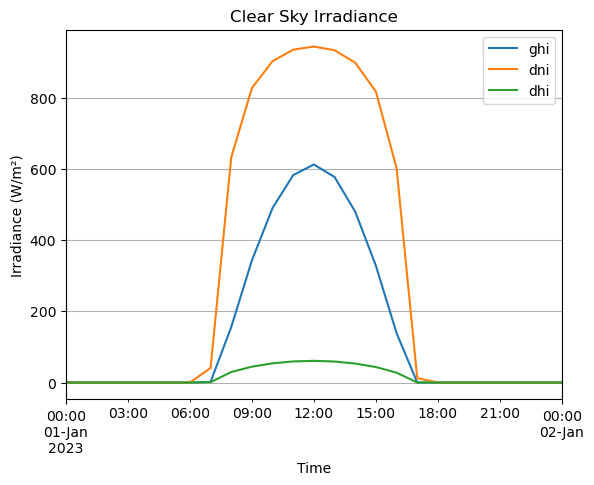

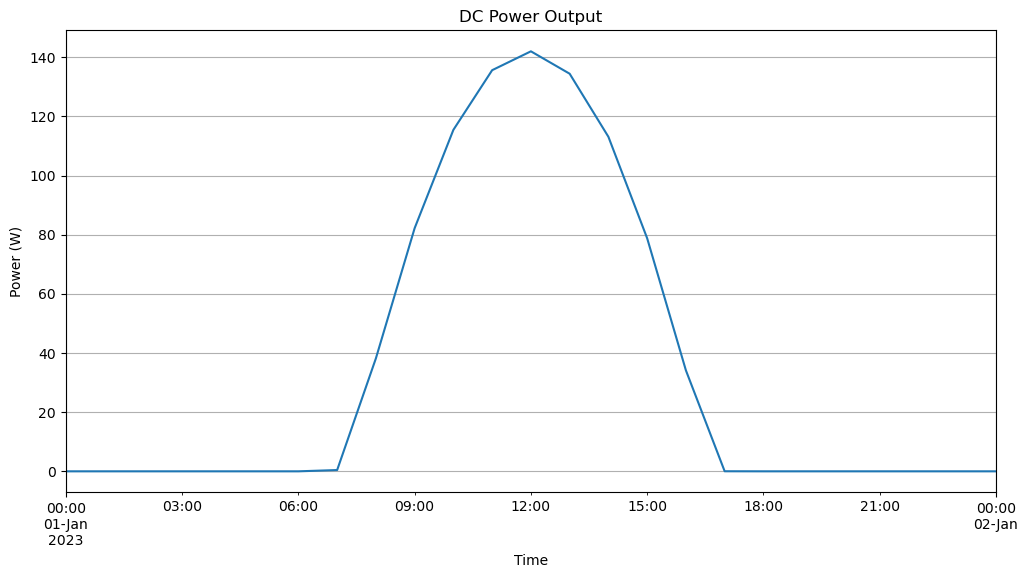

In [9]:
# 绘制辐照度数据  
plt.figure(figsize=(12, 6))  
clearsky.plot()  
plt.title('Clear Sky Irradiance')  
plt.xlabel('Time')  
plt.ylabel('Irradiance (W/m²)')  
plt.grid(True)  
plt.show()  

# 绘制发电量数据  
plt.figure(figsize=(12, 6))  
dc.plot()  
plt.title('DC Power Output')  
plt.xlabel('Time')  
plt.ylabel('Power (W)')  
plt.grid(True)  
plt.show()